# ASSIGNMENT 2: Inferential Statistics - Titanic Dataset
Student Nmae : Meghana Balappa Uppar

USN : 1GV22CS038

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# SECTION 1: Data Understanding

In [5]:
# Task 1: Load dataset
# Download titanic.csv from Kaggle and upload to Colab
df = pd.read_csv('titanic.csv')

In [ ]:
# Task 2: Display shape and columns
print("=" * 60)
print("DATASET SHAPE:", df.shape)
print("\nCOLUMN NAMES:")
print(df.columns.tolist())

DATASET SHAPE: (891, 12)

COLUMN NAMES:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [ ]:
# Task 3: Handle missing values
print("\nMISSING VALUES BEFORE HANDLING:")
print(df.isnull().sum())


MISSING VALUES BEFORE HANDLING:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [ ]:
# Handle missing values
df['Age'].fillna(df['Age'].median(), inplace=True)       # fill Age with median
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)  # fill Embarked with mode
df.drop(columns=['Cabin'], inplace=True)                 # drop Cabin (too many missing)

/tmp/ipykernel_10092/2717724242.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)       # fill Age with median
/tmp/ipykernel_10092/2717724242.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].m

In [ ]:
print("\nMISSING VALUES AFTER HANDLING:")
print(df.isnull().sum())


MISSING VALUES AFTER HANDLING:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


---
# ANSWERS:
 Q: Which columns have missing values?
   - Age (~177 missing), Cabin (~687 missing), Embarked (2 missing)

 Q: What type of variables are present?

  - Numerical: Age, Fare, SibSp, Parch, PassengerId, Pclass
  - Categorical: Sex, Embarked, Name, Ticket
  - Binary: Survived (0 or 1)
---

# SECTION 2: Sampling

In [ ]:
print("\n" + "=" * 60)
print("SECTION 2: SAMPLING")
print("=" * 60)

# Task 1: Take random sample of 100
sample = df.sample(n=100, random_state=42)

# Task 2: Population mean vs Sample mean
pop_mean = df['Age'].mean()
sample_mean = sample['Age'].mean()

print(f"Population Mean (Age) : {pop_mean:.2f}")
print(f"Sample Mean (Age)     : {sample_mean:.2f}")
print(f"Difference            : {abs(pop_mean - sample_mean):.2f}")


SECTION 2: SAMPLING
Population Mean (Age) : 29.36
Sample Mean (Age)     : 29.34
Difference            : 0.03


# ANSWERS:
 Q: Are sample and population mean equal?
   - Not exactly equal, but very close (small difference)

 Q: Why do we use sampling?
  - Real-world datasets are huge; sampling saves time and resources while still giving accurate estimates

# SECTION 3: Central Limit Theorem (CLT)

In [ ]:
print("\n" + "=" * 60)
print("SECTION 3: CENTRAL LIMIT THEOREM")
print("=" * 60)

# Task 1 & 2: Take 500 samples of size 30, store means
sample_means = []
for i in range(500):
    s = df['Age'].sample(n=30, random_state=i)
    sample_means.append(s.mean())

print(f"Mean of sample means : {np.mean(sample_means):.2f}")
print(f"Std of sample means  : {np.std(sample_means):.2f}")


SECTION 3: CENTRAL LIMIT THEOREM
Mean of sample means : 29.31
Std of sample means  : 2.26


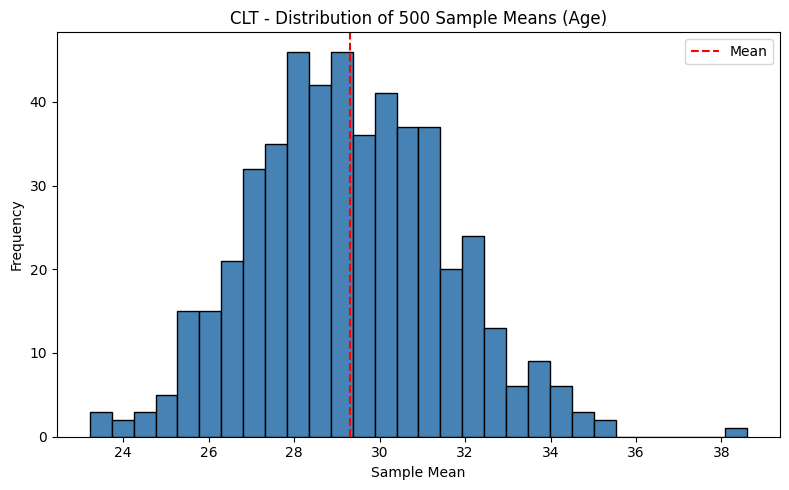

In [ ]:
# Task 3: Plot histogram of sample means
plt.figure(figsize=(8, 5))
plt.hist(sample_means, bins=30, color='steelblue', edgecolor='black')
plt.title('CLT - Distribution of 500 Sample Means (Age)')
plt.xlabel('Sample Mean')
plt.ylabel('Frequency')
plt.axvline(np.mean(sample_means), color='red', linestyle='--', label='Mean')
plt.legend()
plt.tight_layout()
plt.savefig('clt_histogram.png')
plt.show()

---
# ANSWERS:
 Q: Does distribution look normal?
   - Yes! Even though Age is not perfectly normal, the   distribution of sample means looks like a bell curve

 Q: Why does this happen?

  - This is the Central Limit Theorem: regardless of the
  original distribution, sample means follow a normal distribution when sample size is large enough (n >= 30)
---

# SECTION 4: Confidence Interval

In [ ]:
print("\n" + "=" * 60)
print("SECTION 4: CONFIDENCE INTERVAL")
print("=" * 60)

# Task 1: Sample mean and std dev
sample_age = df['Age'].sample(n=100, random_state=42)
s_mean = sample_age.mean()
s_std  = sample_age.std()
n      = len(sample_age)

print(f"Sample Mean : {s_mean:.2f}")
print(f"Sample Std  : {s_std:.2f}")
print(f"Sample Size : {n}")


SECTION 4: CONFIDENCE INTERVAL
Sample Mean : 29.34
Sample Std  : 13.01
Sample Size : 100


In [ ]:
# Task 2: 95% Confidence Interval
confidence = 0.95
se = s_std / np.sqrt(n)                          # standard error
margin = stats.t.ppf((1 + confidence) / 2, df=n-1) * se
lower = s_mean - margin
upper = s_mean + margin

print(f"\n95% Confidence Interval: ({lower:.2f}, {upper:.2f})")
print(f"Margin of Error: ± {margin:.2f}")


95% Confidence Interval: (26.75, 31.92)
Margin of Error: ± 2.58


---
# ANSWERS:
 Q: What does the interval represent?
  - We are 95% confident that the true average age of all Titanic passengers falls within this range

 Q: What happens if sample size increases?

  - The interval becomes narrower (more precise estimate) because standard error decreases as n increases
---

# SECTION 5: Hypothesis Testing (CORE)


SECTION 5: HYPOTHESIS TESTING
Problem: Do males and females have different survival rates?

H0: No difference in survival rate between males and females
H1: There IS a significant difference in survival rates

Male survival rate   : 0.19
Female survival rate : 0.74

t-statistic : -19.2978
p-value     : 0.000000

DECISION:
p < 0.05 → REJECT H0
Conclusion: There IS a significant difference in survival rates.


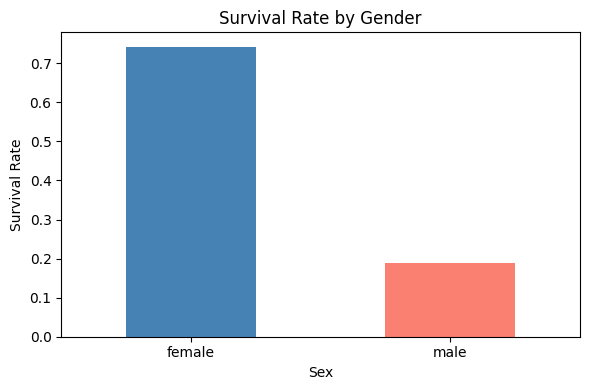

In [ ]:
print("\n" + "=" * 60)
print("SECTION 5: HYPOTHESIS TESTING")
print("Problem: Do males and females have different survival rates?")
print("=" * 60)

# Step 1: Define Hypothesis
print("\nH0: No difference in survival rate between males and females")
print("H1: There IS a significant difference in survival rates")

# Step 2: Perform t-test
male   = df[df['Sex'] == 'male']['Survived']
female = df[df['Sex'] == 'female']['Survived']

t_stat, p_value = stats.ttest_ind(male, female)

print(f"\nMale survival rate   : {male.mean():.2f}")
print(f"Female survival rate : {female.mean():.2f}")
print(f"\nt-statistic : {t_stat:.4f}")
print(f"p-value     : {p_value:.6f}")

# Step 3: Decision
print("\nDECISION:")
if p_value < 0.05:
    print("p < 0.05 → REJECT H0")
    print("Conclusion: There IS a significant difference in survival rates.")
else:
    print("p >= 0.05 → FAIL TO REJECT H0")

# Visualization
plt.figure(figsize=(6, 4))
df.groupby('Sex')['Survived'].mean().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Survival Rate by Gender')
plt.ylabel('Survival Rate')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('survival_by_gender.png')
plt.show()

---
# ANSWERS:
 Q: What is p-value?
  - p-value is the probability of observing the result by chance if H0 is true. Very small p means result is statistically significant

 Q: What conclusion can you draw?

  - p << 0.05, so we reject H0. Females had significantly higher survival rates than males on the Titanic
---

# SECTION 6: Real-World Interpretation

---
1. DID GENDER AFFECT SURVIVAL?
   - Yes. Females had a much higher survival rate (~74%)
     compared to males (~19%). The t-test confirmed this
     difference is statistically significant.

2. CAN WE TRUST THIS CONCLUSION? WHY?
   - Yes, because:
     a) p-value is extremely small (< 0.05)
     b) Large sample size (891 passengers)
     c) The difference in survival rates is very large

3. WHAT ASSUMPTIONS ARE WE MAKING?
   - Samples are independent (males and females are separate groups)
   - Survived column is numerical (0/1), which works for t-test
   - The dataset represents the actual Titanic population fairly

4. HOW CAN THIS HELP IN REAL-WORLD DECISIONS?
   - Emergency protocol design: prioritize vulnerable groups
   - Policy making: "women and children first" backed by data
   - Disaster management: use data to improve rescue plans
   - Insurance/risk analysis: gender-based survival modeling
   ---

# SECTION 7: BONUS - Does Passenger Class Affect Survival?


SECTION 7: BONUS - Does Passenger Class Affect Survival?

H0: Passenger class does NOT affect survival
H1: Passenger class DOES affect survival

Class 1 survival rate : 0.63
Class 2 survival rate : 0.47
Class 3 survival rate : 0.24

F-statistic : 57.9648
p-value     : 0.000000

DECISION:
p < 0.05 → REJECT H0
Conclusion: Passenger class DOES significantly affect survival.


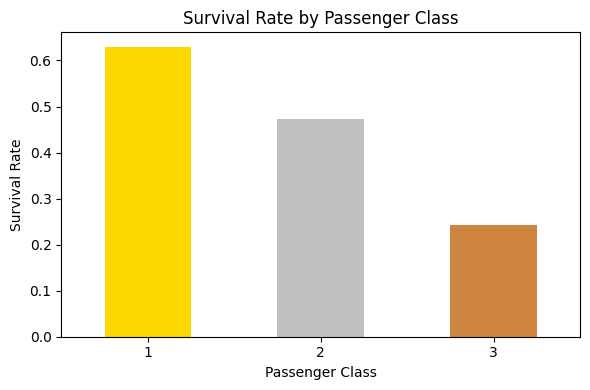

In [6]:
print("\n" + "=" * 60)
print("SECTION 7: BONUS - Does Passenger Class Affect Survival?")
print("=" * 60)

print("\nH0: Passenger class does NOT affect survival")
print("H1: Passenger class DOES affect survival")

# Separate by class
pclass1 = df[df['Pclass'] == 1]['Survived']
pclass2 = df[df['Pclass'] == 2]['Survived']
pclass3 = df[df['Pclass'] == 3]['Survived']

# One-Way ANOVA (3 groups → use ANOVA instead of t-test)
f_stat, p_value_class = stats.f_oneway(pclass1, pclass2, pclass3)

print(f"\nClass 1 survival rate : {pclass1.mean():.2f}")
print(f"Class 2 survival rate : {pclass2.mean():.2f}")
print(f"Class 3 survival rate : {pclass3.mean():.2f}")
print(f"\nF-statistic : {f_stat:.4f}")
print(f"p-value     : {p_value_class:.6f}")

print("\nDECISION:")
if p_value_class < 0.05:
    print("p < 0.05 → REJECT H0")
    print("Conclusion: Passenger class DOES significantly affect survival.")
else:
    print("p >= 0.05 → FAIL TO REJECT H0")

# Visualization
plt.figure(figsize=(6, 4))
df.groupby('Pclass')['Survived'].mean().plot(kind='bar', color=['gold', 'silver', 'peru'])
plt.title('Survival Rate by Passenger Class')
plt.ylabel('Survival Rate')
plt.xlabel('Passenger Class')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('survival_by_class.png')
plt.show()